The classic Olivetti faces dataset contains 400 grayscale 64 × 64–
pixel images of faces. Each image is flattened to a 1D vector of
size 4,096. Forty different people were photographed (10 times
each), and the usual task is to train a model that can predict which
person is represented in each picture. Load the dataset using the
sklearn.datasets.fetch_olivetti_faces()
function, then split it into a training set, a validation set, and a test
set (note that the dataset is already scaled between 0 and 1). Since
the dataset is quite small, you will probably want to use stratified
sampling to ensure that there are the same number of images per
person in each set. Next, cluster the images using k-means, and
ensure that you have a good number of clusters (using one of the
techniques discussed in this chapter). Visualize the clusters: do you
see similar faces in each cluster?

In [1]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import numpy as np
data = fetch_olivetti_faces()
X, y = data.data, data.target  # X: (400, 4096), y: person id 0–39
# 60% train, 20% validation, 20% test — stratified (6 / 2 / 2 per person)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("pixel range:", float(X.min()), "to", float(X.max()))
assert np.all(np.bincount(y_train.astype(int)) == 6)
assert np.all(np.bincount(y_val.astype(int)) == 2)
assert np.all(np.bincount(y_test.astype(int)) == 2)
print("stratified: 6 train / 2 val / 2 test per person")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/aryamanwade/scikit_learn_data
X_train: (240, 4096) X_val: (80, 4096) X_test: (80, 4096)
pixel range: 0.0 to 1.0
stratified: 6 train / 2 val / 2 test per person


K-means with best siloutte score

In [2]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# search range for k (tune max: e.g. 5–100 or 2–40)
k_min, k_max = 2, 40
k_values = range(k_min, k_max + 1)
best_k = None
best_score = -1.0
scores = {}
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)
    s = silhouette_score(X_train, labels, metric="euclidean")
    scores[k] = s
    if s > best_score:
        best_score = s
        best_k = k
print(f"best k = {best_k}, silhouette = {best_score:.4f}")
# final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_labels = kmeans_final.fit_predict(X_train)

best k = 2, silhouette = 0.1590


plot

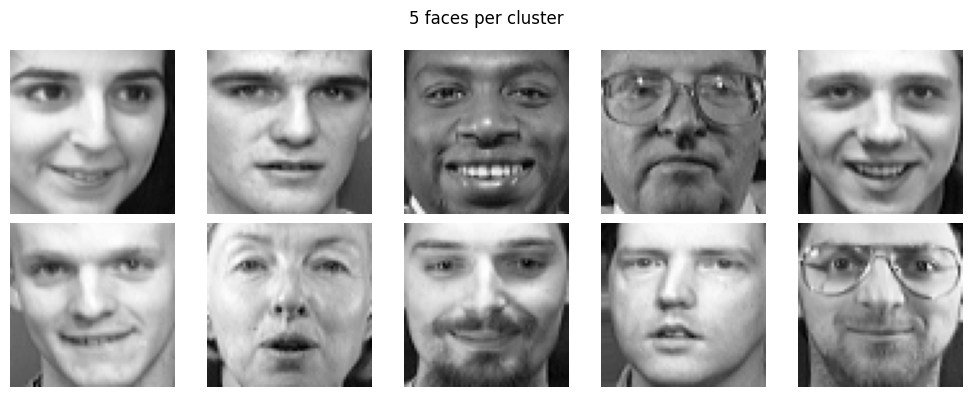

In [3]:
import numpy as np
import matplotlib.pyplot as plt
def plot_two_clusters(X, labels, id_a, id_b, n=5, shape=(64, 64)):
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
    for row, cid in enumerate([id_a, id_b]):
        idx = np.where(labels == cid)[0][:n]
        for col, j in enumerate(idx):
            axes[row, col].imshow(X[j].reshape(shape), cmap="gray")
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(f"cluster {cid}", fontsize=11)
    plt.suptitle(f"{n} faces per cluster")
    plt.tight_layout()
    plt.show()
# Example: clusters numbered 1 and 2 (sklearn uses 0..K-1; if your labels are 0-based, use 0 and 1)
plot_two_clusters(X_train, train_labels, id_a=0, id_b=1, n=5)

K-means might not be great, algorithim was not able to find distinct clusters

Continuing with the Olivetti faces dataset, train a classifier to
predict which person is represented in each picture, and evaluate it
on the validation set. Next, use k-means as a dimensionality
reduction tool, and train a classifier on the reduced set. Search for
the number of clusters that allows the classifier to get the best
performance: what performance can you reach? What if you
append the features from the reduced set to the original features
(again, searching for the best number of clusters)?

SVM

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Optional but often helps SVM on high-dimensional pixels
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
])
clf.fit(X_train, y_train)
y_val_pred = clf.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, digits=4))

Validation accuracy: 0.9375
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         2
           1     1.0000    1.0000    1.0000         2
           2     1.0000    0.5000    0.6667         2
           3     0.6667    1.0000    0.8000         2
           4     1.0000    1.0000    1.0000         2
           5     1.0000    1.0000    1.0000         2
           6     1.0000    1.0000    1.0000         2
           7     1.0000    1.0000    1.0000         2
           8     1.0000    1.0000    1.0000         2
           9     1.0000    0.5000    0.6667         2
          10     1.0000    1.0000    1.0000         2
          11     0.6667    1.0000    0.8000         2
          12     1.0000    0.5000    0.6667         2
          13     1.0000    1.0000    1.0000         2
          14     1.0000    1.0000    1.0000         2
          15     1.0000    1.0000    1.0000         2
          16     1.0000    1.0000    1.0000         2

Using k means, for dimensionality reduction. Get k centroids, distance from each is a feature

In [ ]:
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

k_list = [2, 5, 10, 15, 20, 25, 30, 35, 40]
results = {}

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    X_train_km = km.fit_transform(X_train)
    X_val_km = km.transform(X_val)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
    ])
    clf.fit(X_train_km, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_km))
    results[k] = val_acc
    print(f"k={k:2d}  val_accuracy={val_acc:.4f}")

best_k = max(results, key=results.get)
print(f"\nbest k = {best_k}  val_accuracy = {results[best_k]:.4f}")

Using k means vals with orignal data

In [7]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# k-means distances + original pixels (concatenate along features)
k_list = [2, 5, 10, 15, 20, 25, 30, 35, 40]
results = {}

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    X_train_km = km.fit_transform(X_train)
    X_val_km = km.transform(X_val)

    X_train_aug = np.hstack([X_train, X_train_km])
    X_val_aug = np.hstack([X_val, X_val_km])

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
    ])
    clf.fit(X_train_aug, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_aug))
    results[k] = val_acc
    print(f"k={k:2d}  val_accuracy={val_acc:.4f}  (4096 + {k} features)")

best_k = max(results, key=results.get)
print(f"\nbest k = {best_k}  val_accuracy = {results[best_k]:.4f}")

k= 2  val_accuracy=0.9375  (4096 + 2 features)
k= 5  val_accuracy=0.9375  (4096 + 5 features)
k=10  val_accuracy=0.9375  (4096 + 10 features)
k=15  val_accuracy=0.9375  (4096 + 15 features)
k=20  val_accuracy=0.9375  (4096 + 20 features)
k=25  val_accuracy=0.9375  (4096 + 25 features)
k=30  val_accuracy=0.9375  (4096 + 30 features)
k=35  val_accuracy=0.9375  (4096 + 35 features)
k=40  val_accuracy=0.9375  (4096 + 40 features)

best k = 2  val_accuracy = 0.9375


K means doesnt help the model


Train a Gaussian mixture model on the Olivetti faces dataset. To
speed up the algorithm, you should probably reduce the dataset’s
dimensionality (e.g., use PCA, preserving 99% of the variance).
Use the model to generate some new faces (using the sample()
method), and visualize them (if you used PCA, you will need to
use its inverse_transform() method). Try to modify some
images (e.g., rotate, flip, darken) and see if the model can detect
the anomalies (i.e., compare the output of the
score_samples() method for normal images and for
anomalies).

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)
print("original dim:", X_train.shape[1])
print("PCA dim (99% variance):", X_train_pca.shape[1])
print("explained variance ratio (sum):", float(pca.explained_variance_ratio_.sum()))

original dim: 4096
PCA dim (99% variance): 176
explained variance ratio (sum): 0.9900876879692078


In [9]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=40,       # tune: e.g. 20–80 or match #people; 40 is a natural try
    covariance_type="full",  # or "diag" / "tied" for fewer params / speed
    random_state=42,
    n_init=5,
    max_iter=200,
)
gmm.fit(X_train_pca)

# optional: cluster-like soft assignments or log-likelihood
train_resp = gmm.predict_proba(X_train_pca)
val_loglik = gmm.score(X_val_pca)   # average log-likelihood per sample
print("val mean log-likelihood:", val_loglik)

val mean log-likelihood: -8092315.0


Generate new images using the model and visualise, using inverse PCA transform

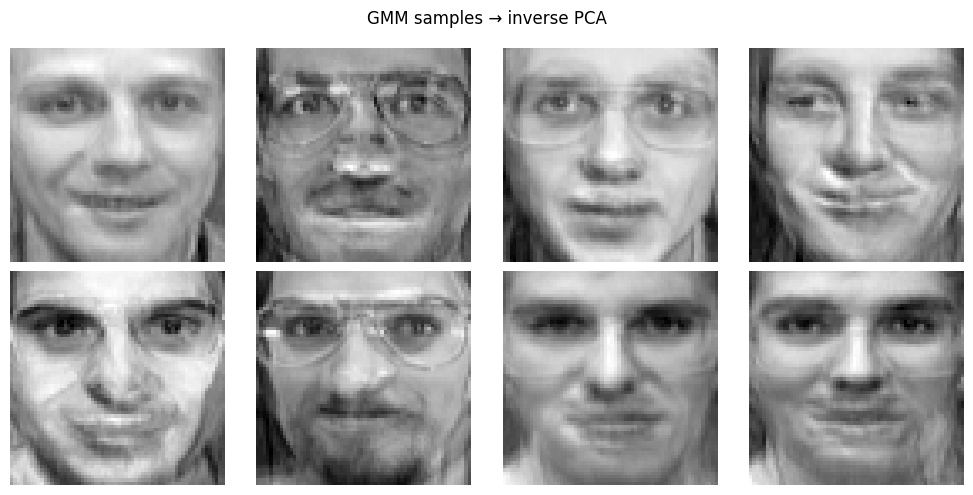

In [10]:
import numpy as np
import matplotlib.pyplot as plt
n_new = 8
# GMM was fit on PCA space; sample there
X_new_pca, _ = gmm.sample(n_new)
# back to pixel space
X_new = pca.inverse_transform(X_new_pca)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img in zip(axes.ravel(), X_new):
    ax.imshow(img.reshape(64, 64), cmap="gray")
    ax.axis("off")
plt.suptitle("GMM samples → inverse PCA")
plt.tight_layout()
plt.show()

Test anomaly detection with 4 images
Upside down, really black, reall white, 2 faces combined


In [11]:
import numpy as np

def vec(x):
    return np.asarray(x).reshape(-1)

def img(x):
    return x.reshape(64, 64)

# Four reference faces (any 4 rows from train/val)
b0, b1, b2, b3 = X_train[0], X_train[1], X_train[2], X_train[3]

# 1) upside down
x_upside = vec(np.flipud(img(b0)))

# 2) very dark
x_dark = np.clip(b1 * 0.08, 0.0, 1.0)

# 3) very bright / washed
x_white = np.clip(np.ones_like(b2) * 0.92, 0.0, 1.0)

# 4) blend two different faces
x_blend = np.clip((b2 + b3) / 2.0, 0.0, 1.0)

X_normal = np.vstack([b0, b1, b2, b3])
X_anom = np.vstack([x_upside, x_dark, x_white, x_blend])

Z_n = pca.transform(X_normal)
Z_a = pca.transform(X_anom)

s_n = gmm.score_samples(Z_n)
s_a = gmm.score_samples(Z_a)

names = ["original×4", "upside-down", "very dark", "very white", "blend two"]
print("mean log-lik (normal batch):", s_n.mean())
for name, sn, sa in zip(
    ["orig[0]", "orig[1]", "orig[2]", "orig[3]"],
    s_n,
    s_a,
):
    print(f"  {name:12}  normal={sn:10.3f}   anomaly pair={sa:10.3f}")

print("\nper anomaly type (vs its reference row):")
print(f"  upside-down vs ref0: normal={s_n[0]:.3f}  anomaly={s_a[0]:.3f}")
print(f"  dark      vs ref1: normal={s_n[1]:.3f}  anomaly={s_a[1]:.3f}")
print(f"  white     vs ref2: normal={s_n[2]:.3f}  anomaly={s_a[2]:.3f}")
print(f"  blend     vs ref2/3: compare s_n[2],s_n[3] to s_a[3]:")
print(f"       anomaly(blend)={s_a[3]:.3f}")

mean log-lik (normal batch): 995.09094
  orig[0]       normal=   963.369   anomaly pair=-33754688.000
  orig[1]       normal=  1007.915   anomaly pair=-154330992.000
  orig[2]       normal=  1015.931   anomaly pair=-63357092.000
  orig[3]       normal=   993.148   anomaly pair=-10854892.000

per anomaly type (vs its reference row):
  upside-down vs ref0: normal=963.369  anomaly=-33754688.000
  dark      vs ref1: normal=1007.915  anomaly=-154330992.000
  white     vs ref2: normal=1015.931  anomaly=-63357092.000
  blend     vs ref2/3: compare s_n[2],s_n[3] to s_a[3]:
       anomaly(blend)=-10854892.000


Some dimensionality reduction techniques can also be used for
anomaly detection. For example, take the Olivetti faces dataset and
reduce it with PCA, preserving 99% of the variance. Then compute
the reconstruction error for each image. Next, take some of the
modified images you built in the previous exercise and look at their
reconstruction error: notice how much larger it is. If you plot a
reconstructed image, you will see why: it tries to reconstruct a
normal face.

mean recon MSE — normal:      0.0022529706
mean recon MSE — upside down: 0.007693784
ratio (upside / normal):      3.4149508


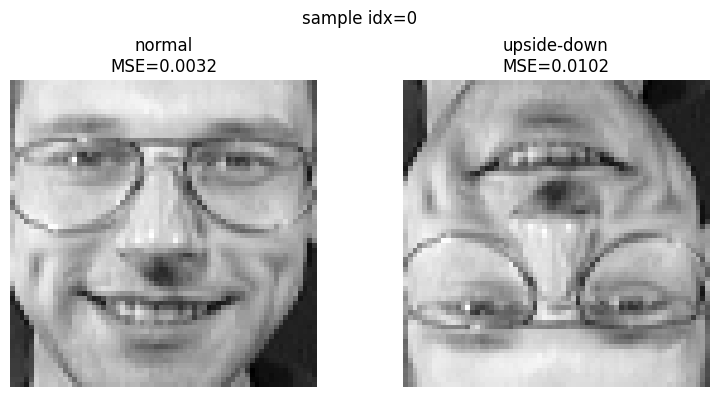

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def recon_mse_per_image(X, pca):
    Z = pca.transform(X)
    X_hat = pca.inverse_transform(Z)
    return np.mean((X - X_hat) ** 2, axis=1)

mse_normal = recon_mse_per_image(X_val, pca)
X_up = np.stack([
    np.flipud(x.reshape(64, 64)).ravel()
    for x in X_val
])
mse_upside = recon_mse_per_image(X_up, pca)

print("mean recon MSE — normal:     ", mse_normal.mean())
print("mean recon MSE — upside down:", mse_upside.mean())
print("ratio (upside / normal):     ", mse_upside.mean() / mse_normal.mean())

idx = 0
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_val[idx].reshape(64, 64), cmap="gray")
axes[0].set_title(f"normal\nMSE={mse_normal[idx]:.4f}")
axes[0].axis("off")
axes[1].imshow(X_up[idx].reshape(64, 64), cmap="gray")
axes[1].set_title(f"upside-down\nMSE={mse_upside[idx]:.4f}")
axes[1].axis("off")
plt.suptitle(f"sample idx={idx}")
plt.tight_layout()
plt.show()


High reconstruction MSE ⇒ likely anomaly